In [89]:
import pandas as pd 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot  as plt 
from sklearn.decomposition import PCA
import numpy as np


In [90]:
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [91]:
print(df.Channel.unique())
print(df.Region.unique())
df.shape

[2 1]
[3 1 2]


(440, 8)

In [92]:
df_reg_cha = df[["Region", "Channel"]]
df_reg_cha

,Region,Channel
0,3,2
1,3,2
2,3,2
3,3,1
4,3,2
...,...,...
435,3,1
436,3,1
437,3,2
438,3,1


In [93]:
df = df.drop(["Region", "Channel"], axis=1)
df.columns.tolist()

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

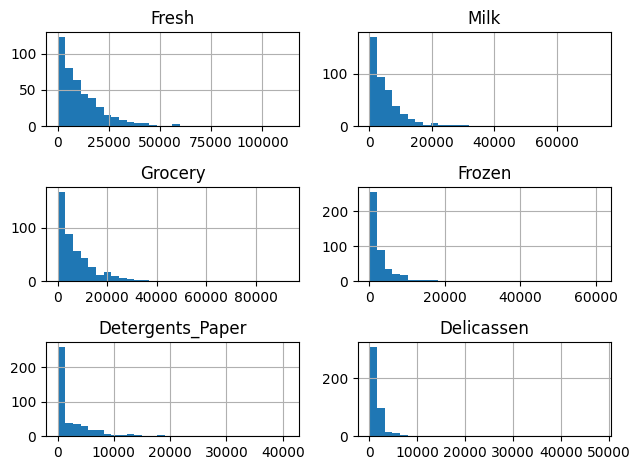

In [94]:
df.hist(bins=30)
plt.tight_layout()
plt.show()

In [95]:
sc = StandardScaler()
features = np.log1p(df)
print(features.dtypes)
scaled_data = sc.fit_transform(features)
scaled_data.shape

Fresh               float64
Milk                float64
Grocery             float64
Frozen              float64
Detergents_Paper    float64
Delicassen          float64
dtype: object


(440, 6)

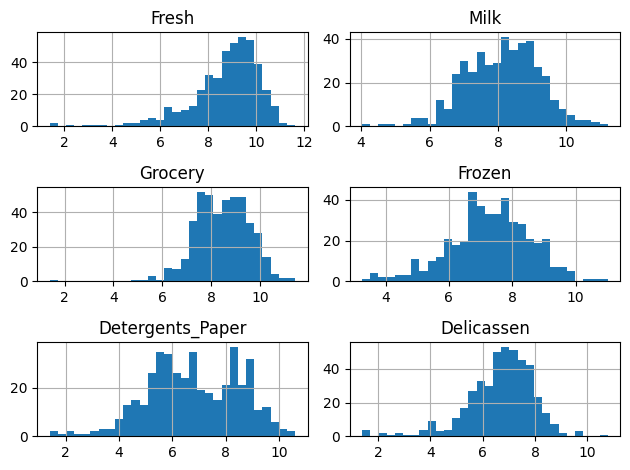

In [96]:
features.hist(bins=30)
plt.tight_layout()
plt.show()

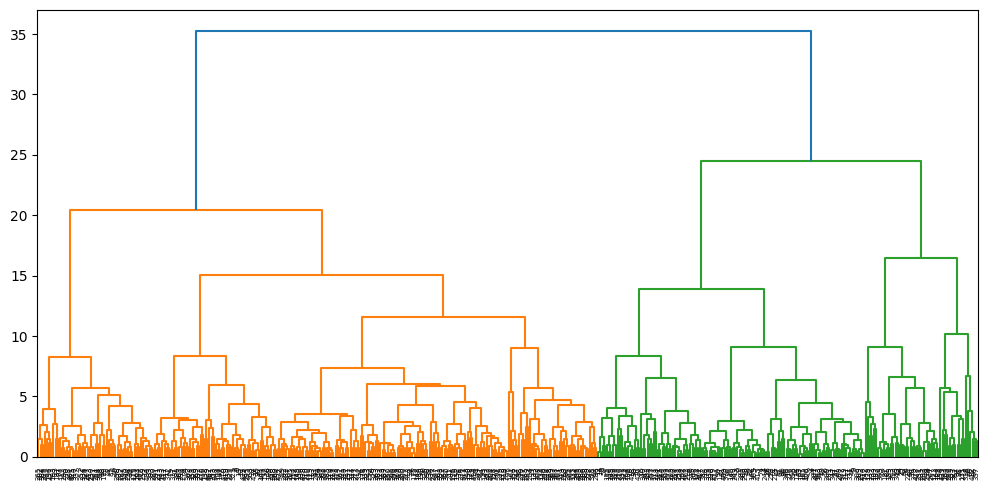

In [97]:
# ploting the dendrogram for the optimal k selection 

from scipy.cluster.hierarchy import dendrogram,linkage

link = linkage(scaled_data, method="ward", metric="euclidean")
plt.figure(figsize=(10,5))
dendrogram(link)
plt.tight_layout()
plt.show()

In [98]:
results = []
for i  in range(2,13):

    agg = AgglomerativeClustering(n_clusters=i,linkage='ward')
    cluster = agg.fit_predict(scaled_data)
    results.append({
        'k': i,
        'silhouette': silhouette_score(scaled_data, cluster),
        'calinski_harabasz': calinski_harabasz_score(scaled_data, cluster),
        'davies_bouldin': davies_bouldin_score(scaled_data, cluster),
        'min_cluster_size': pd.Series(cluster).value_counts().min(),
    })

In [99]:
for i in results:
    print(i)
    

{'k': 2, 'silhouette': 0.25849531748001764, 'calinski_harabasz': 134.62446054306855, 'davies_bouldin': 1.6003633212363932, 'min_cluster_size': np.int64(178)}
{'k': 3, 'silhouette': 0.2546567404941345, 'calinski_harabasz': 116.79927751929242, 'davies_bouldin': 1.5389948670687703, 'min_cluster_size': np.int64(53)}
{'k': 4, 'silhouette': 0.2020795686473931, 'calinski_harabasz': 108.60672962333317, 'davies_bouldin': 1.5210907132699094, 'min_cluster_size': np.int64(53)}
{'k': 5, 'silhouette': 0.20254726415449098, 'calinski_harabasz': 100.01460625558079, 'davies_bouldin': 1.386197948160201, 'min_cluster_size': np.int64(18)}
{'k': 6, 'silhouette': 0.17070717535560317, 'calinski_harabasz': 94.8565747327311, 'davies_bouldin': 1.489515856837887, 'min_cluster_size': np.int64(18)}
{'k': 7, 'silhouette': 0.1633381633179497, 'calinski_harabasz': 91.30053265742902, 'davies_bouldin': 1.4982766240510041, 'min_cluster_size': np.int64(18)}
{'k': 8, 'silhouette': 0.14821716334902965, 'calinski_harabasz': 

In [100]:
model_k2 = AgglomerativeClustering(n_clusters=2,linkage="ward")
df["Clusters_k2"] = model_k2.fit_predict(scaled_data)
df.Clusters_k2.value_counts()


Clusters_k2
1    262
0    178
Name: count, dtype: int64

In [101]:
model_k3 = AgglomerativeClustering(n_clusters=3,linkage="ward")
df["Clusters_k3"] = model_k3.fit_predict(scaled_data)
df.Clusters_k3.value_counts()


Clusters_k3
0    262
2    125
1     53
Name: count, dtype: int64

In [102]:
pca = PCA(n_components=2)

data = pca.fit_transform(scaled_data)

data.shape

(440, 2)

[]

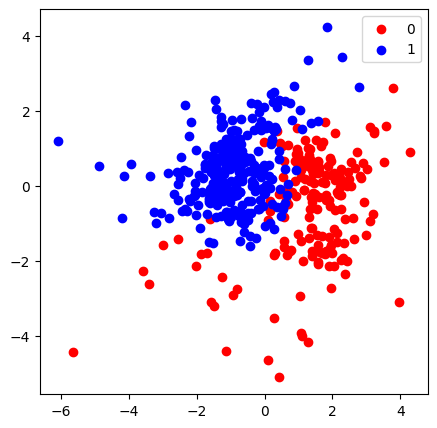

In [103]:
# PLot for when cluster is k =2
plt.figure(figsize=(5,5))
plt.scatter(data[df['Clusters_k2']==0,0], data[df["Clusters_k2"] == 0,1], color = "red", label = "0")
plt.scatter(data[df['Clusters_k2']==1,0], data[df["Clusters_k2"] == 1,1], color = "blue", label = 1)
plt.legend()
plt.plot()

[]

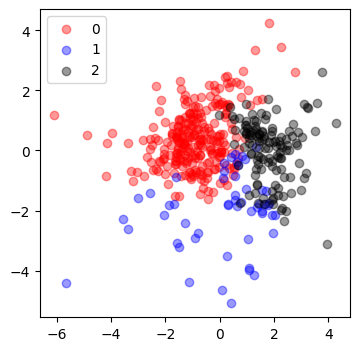

In [104]:
# PLot for when cluster is k =3
plt.figure(figsize=(4,4))
plt.scatter(data[df['Clusters_k3']==0,0], data[df["Clusters_k3"] == 0,1], color = "red",alpha=0.4, label = "0")
plt.scatter(data[df['Clusters_k3']==1,0], data[df["Clusters_k3"] == 1,1], color = "blue",alpha=0.4 ,label = "1")
plt.scatter(data[df['Clusters_k3']==2,0], data[df["Clusters_k3"] == 2,1], color = "black",alpha=0.4,label= "2")
plt.legend()
plt.plot()

In [105]:
# averaging
features.groupby(df.Clusters_k2).mean()

# for 
# the cluster 0 customers are high grocery,milk,detergent and low frozen products, delicassen 
# cluster 1 customers are high fresh buyes and mid level milk grocery frozen tho it more than the clsuter 0 buyers and  delicassen buyer, and they buy the least amount of detergents paper

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Clusters_k2,,,,,,
0,8.023472,8.794548,9.263817,6.682880,8.186176,6.576662
1,9.214732,7.664433,7.884011,7.724517,5.844444,6.735251


In [106]:
features.groupby(df.Clusters_k3).mean()

# For k= 3

# k = cluster 0  buys the most amount of fresh products and they buy the leaste detergents  and delicassen is low-mid 
# cluster 1 buys the milk in high-mid quantity same for the groceries the delicassen is the least bought buy them while other are in mid range 
# cluster 2 buys the most amount of the milk and groceries detergent paper anmmilk and the fresh products frozena d is the least bought in them and the delicassen is in mid range 

# we can say that cluster 0 are the people that focus on the freshness more and other they are not buying maybe they are travellers who wan to store stuff for a long time
# cluster 1 are the the people that aveerage to below average consumers 
# cluster 2 are the people that buy stuff on frequently are loyal and frequent consumers 

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Clusters_k3,,,,,,
0,9.214732,7.664433,7.884011,7.724517,5.844444,6.735251
1,6.969703,8.079974,8.639716,6.319112,7.143589,4.642733
2,8.470271,9.097527,9.528435,6.837118,8.628233,7.396648


In [112]:
feautures_raw = df
df_raw = feautures_raw.groupby(df.Clusters_k2).median()
df_raw

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clusters_k3
Clusters_k2,,,,,,,
0,4499.5,7339.0,11099.0,957.0,4584.0,1189.0,2.0
1,11113.0,2028.0,2583.5,2382.0,358.5,864.0,0.0


In [117]:
pd.crosstab(df.Clusters_k2, df_reg_cha['Channel']) 

Channel,1,2
Clusters_k2,,
0,47,131
1,251,11


In [113]:
df_raw = feautures_raw.groupby(df.Clusters_k3).median()
df_raw

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clusters_k2
Clusters_k3,,,,,,,
0,11113.0,2028.0,2583.5,2382.0,358.5,864.0,1.0
1,1689.0,4230.0,7854.0,661.0,2970.0,156.0,0.0
2,5981.0,8259.0,12469.0,1148.0,5618.0,1682.0,0.0


In [115]:
print(df.Clusters_k3.value_counts())
pd.crosstab(df.Clusters_k3, df_reg_cha['Channel']) 

Clusters_k3
0    262
2    125
1     53
Name: count, dtype: int64


Channel,1,2
Clusters_k3,,
0,251,11
1,27,26
2,20,105


In [ ]:
# I chose k=2 because it had the highest Calinski-Harabasz score and a silhouette tied with k=3. The two clusters recovered the Horeca/Retail channel for about 87% of customers, even though Channel wasn't used in clustering. k=3 only carved out a small, mixed-channel, low-spending group and added no channel information.

# Clustering Metrics Used

## Silhouette Score
- Measures how close each point is to its own cluster compared to the nearest other cluster.
- **Range:** -1 to 1
- **Better:** Higher. Near 0 means clusters overlap.

## Calinski-Harabasz Index
- Ratio of between-cluster spread to within-cluster spread.
- **Better:** Higher.
- Favors compact, well-separated clusters. It often keeps rising as k grows, so use it with caution.

## Davies-Bouldin Index
- Average similarity between each cluster and its most similar neighbor (spread relative to the distance between centers).
- **Better:** Lower. 0 is ideal.

## Minimum Cluster Size (not a formal metric)
- A quick sanity check to catch clusters made of just a few outliers.

## Caveat
These are **internal metrics**, computed from the data alone, so they can disagree with each other. Use them to shortlist k, then confirm with cluster profiling and outside checks such as the `Channel` column.